In [125]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF

import torch
import torch.nn as nn
import torch.nn.functional as nf
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [126]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float

In [127]:
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

In [128]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [129]:
data, targets = next(iter(train_loader))

In [130]:
data1, targets1 = next(iter(test_loader))

torch.Size([128, 1, 28, 28])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.3647, 0.6431, 1.0000,
          0.8235, 0.3294, 0.0353, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0941, 0.9922, 0.9922, 0.9922,
          0.9922, 0.9922, 0.

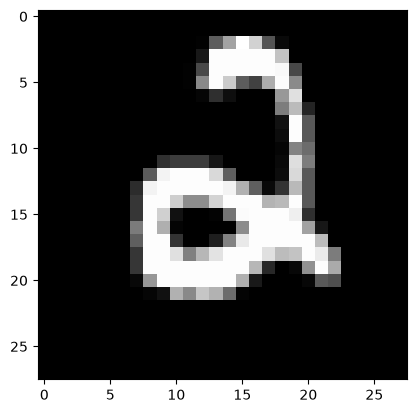

In [131]:
print(data.shape)
print(data[0])
print(data[0]*255)
plt.imshow(data[0].squeeze(),cmap='gray')
plt.show()

In [132]:
# Network Architecture
num_inputs = 28*28
num_hidden = 1200
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.95
spike_grad = surrogate.fast_sigmoid(slope=25)

In [133]:
from snntorch import spikegen

spike_data = spikegen.latency(
    data,
    num_steps=num_steps,
    normalize=True
)

print(spike_data.shape)
print(spike_data[:,0,0,:,:])

torch.Size([25, 128, 1, 28, 28])
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0.

In [134]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):

        # x shape:
        # [num_steps, batch_size, 1, 28, 28]

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(num_steps):

            # Take one timestep
            x_t = x[step]

            # Flatten image
            x_t = x_t.view(x_t.size(0), -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk_rec.append(spk2)
            mem_rec.append(mem2)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

net = Net()

In [135]:
spike_data = spikegen.latency(
    data,
    num_steps=num_steps,
    normalize=True
)

spk_rec1, mem_rec = net(spike_data)

print(spk_rec1.shape)

torch.Size([25, 128, 10])


In [145]:
loss = SF.ce_temporal_loss()
loss_val = loss(spk_rec1, targets)

print(loss_val.item())
print(SF.accuracy_temporal(spk_rec1, targets) * 100)

2.3025853633880615
10.15625


In [146]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

In [147]:
loss_val = loss(spk_rec1, targets)
acc = SF.accuracy_temporal(spk_rec1, targets)

In [148]:
print(loss_val.item())
print(acc*100)

2.3025853633880615
10.15625


In [149]:
def batch_accuracy(t_l, net, num_steps):
    with torch.no_grad():
        total = 0
        acc = 0
        net.eval()

        train_loader = iter(t_l)

        for data, targets in train_loader:

            spike_data = spikegen.latency(
                data,
                num_steps=num_steps,
                normalize=True
            )

            spk_rec, _ = net(spike_data)

            acc += SF.accuracy_temporal(spk_rec, targets) * spk_rec.size(1)
            total += spk_rec.size(1)

    return acc/total

In [150]:
test_acc = batch_accuracy(test_loader, net, num_steps)

In [151]:
print(test_acc*100)

9.935897435897436


original no  4
predicted no  0


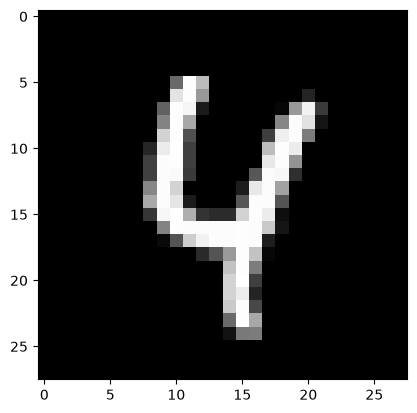

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [152]:
n = 13

# Pick one image from the test batch
single_img = data1[n].unsqueeze(0)

# Convert image to latency spike train
spike_img = spikegen.latency(
    single_img,
    num_steps=num_steps,
    normalize=True
)

# Run through network
s, m = net(spike_img)

first_spike = torch.full((num_outputs,), num_steps)
for t in range(num_steps):
    for neuron in range(num_outputs):
        if s[t,0,neuron] == 1 and first_spike[neuron] == num_steps:
            first_spike[neuron] = t
pc = first_spike.argmin()
print("original no ", targets1[n].item())
print("predicted no ", pc.item())

plt.imshow(data1[n].squeeze(), cmap='gray')
plt.show()

print(s)

In [153]:
num_epochs = 3
loss_hist = []
test_acc_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    for data, targets in iter(train_loader):

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True
        )

        spk_rec, _ = net(spike_data)

        loss_val = loss(spk_rec, targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        loss_hist.append(loss_val.item())

        if counter % 50 == 0:
            with torch.no_grad():

                net.eval()

                test_acc = batch_accuracy(
                    test_loader,
                    net,
                    num_steps
                )

                print(
                    f"Iteration {counter}, Test Acc: {test_acc * 100:.2f}%\n"
                )

                test_acc_hist.append(test_acc.item())

                net.train()

        counter += 1

Iteration 0, Test Acc: 10.18%



KeyboardInterrupt: 

In [ ]:
# Take one batch
data, targets = next(iter(test_loader))

spike_data = spikegen.latency(
    data,
    num_steps=num_steps,
    normalize=True
)

spk_rec, _ = net(spike_data)

print("Total spikes:", spk_rec.sum().item())
print("Max value:", spk_rec.max().item())
print("Shape:", spk_rec.shape)

In [121]:
print(spk_rec.sum(dim=(0,2)))

tensor([2., 2., 1., 1., 4., 3., 1., 4., 1., 3., 4., 3., 3., 3., 4., 3., 2., 3.,
        2., 3., 2., 1., 2., 3., 2., 2., 3., 2., 3., 3., 3., 2., 3., 3., 3., 3.,
        2., 5., 3., 1., 3., 2., 2., 1., 3., 3., 3., 3., 2., 4., 2., 4., 3., 3.,
        3., 2., 1., 2., 2., 2., 2., 1., 2., 2., 3., 2., 3., 2., 1., 1., 4., 3.,
        1., 4., 4., 2., 3., 3., 3., 1., 3., 4., 2., 2., 5., 3., 2., 3., 2., 2.,
        2., 2., 3., 2., 4., 2., 4., 3., 1., 3., 3., 1., 2., 2., 2., 3., 3., 1.,
        4., 2., 4., 3., 2., 2., 2., 2., 3., 3., 3., 3., 1., 3., 1., 2., 2., 4.,
        3., 3.], grad_fn=<SumBackward1>)


In [122]:
print(spk_rec.sum(dim=(0,1)))

tensor([25., 18., 37., 48., 41., 24., 26., 27., 41., 36.],
       grad_fn=<SumBackward1>)


In [ ]:
n = 13

# Pick one image from the test batch
single_img = data1[n].unsqueeze(0)

# Convert image to latency spike train
spike_img = spikegen.latency(
    single_img,
    num_steps=num_steps,
    normalize=True
)

# Run through network
s, m = net(spike_img)

first_spike = torch.full((num_outputs,), num_steps)
for t in range(num_steps):
    for neuron in range(num_outputs):
        if s[t,0,neuron] == 1 and first_spike[neuron] == num_steps:
            first_spike[neuron] = t
pc = first_spike.argmin()
print("original no ", targets1[n].item())
print("predicted no ", pc.item())

plt.imshow(data1[n].squeeze(), cmap='gray')
plt.show()

print(s)

In [25]:
wrong_imgs = []
wrong_preds = []
wrong_labels = []

net.eval()

with torch.no_grad():

    for data, targets in test_loader:

        # Convert batch to latency spike train
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True
        )

        # Forward pass
        spk_rec, mem_rec = net(spike_data)

        # Sum spikes over time
        spk_sum = spk_rec.sum(dim=0)

        # Predicted class
        preds = spk_sum.argmax(dim=1)

        # Find wrong predictions
        wrong = preds != targets

        wrong_imgs.extend(data[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(targets[wrong])

print("Total wrong predictions:", len(wrong_imgs))

Total wrong predictions: 764


Actual : 9
Predicted : 0


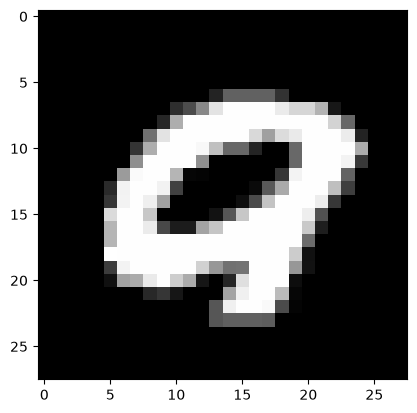

In [26]:
n = 211
plt.imshow(wrong_imgs[n].squeeze(), cmap='gray')

print("Actual :", wrong_labels[n].item())
print("Predicted :", wrong_preds[n].item())

plt.show()

NameError: name 'latency_test_acc_hist' is not defined